# California housing 

## Regression - förutsäga bostadsvärde

I denna notebook analyseras ett dataset som beskriver bostadsvärden i Kalifornien. 
Målet är att uteckla en modell för att förutsäga medianvärdet på bostäder i olika områden. Modellen kan sen användas som beslutsstöd vid exempelvis investeringar eller planering inom bostadsmarknaden för att ge en uppskattning av förväntade bostadspriser.

Strukturen är följande:
- Dataförståelse & EDA - Undersöka datasetet, visuell analys av variabler
- Split + preprocessing - förbered datan för modellträning
- Modellering - träna och jämföra flera modeller
- Optimera en modell - optimera den bästa modellen
- Utvärdering testdata - den optimerade modellen utvärderas på testdata
- Resultat och rekommendation - resultaten sammanfattas och en rekommendation ges

## Dataförståelse och EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [6]:
df = pd.read_csv("housing.csv")

display(df.head())

print()
df.info()

print("\n*** Sammanfattning datatset ***")
display(df.describe().T)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

*** Sammanfattning datatset ***


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [3]:
print("--Datatyper i datasetet--\n")
print(df.dtypes)

--Datatyper i datasetet--

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


### Saknade värden

- För att hantera saknade värden så imputerar vi dem med medianen, för att minimera påverkan av outliers. Här används median istället för medelvärde då den är snedfördelad, endast ```total_bedrooms``` innehåller saknade värden.

In [4]:
print("Shape:", df.shape)
print("\n*** Saknade värden per kolumn ***\n")
print(df.isna().sum())

Shape: (20640, 10)

*** Saknade värden per kolumn ***

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


### Feature engineering

In [5]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

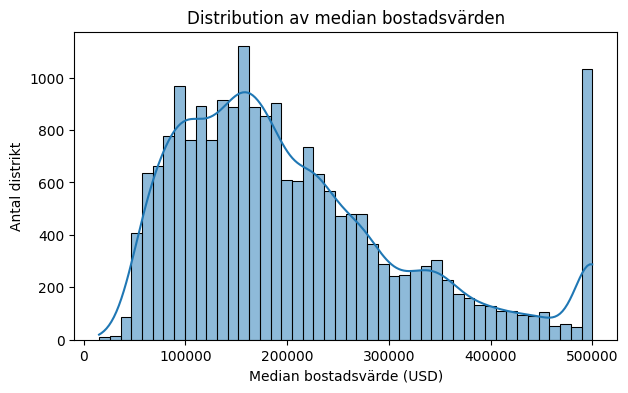

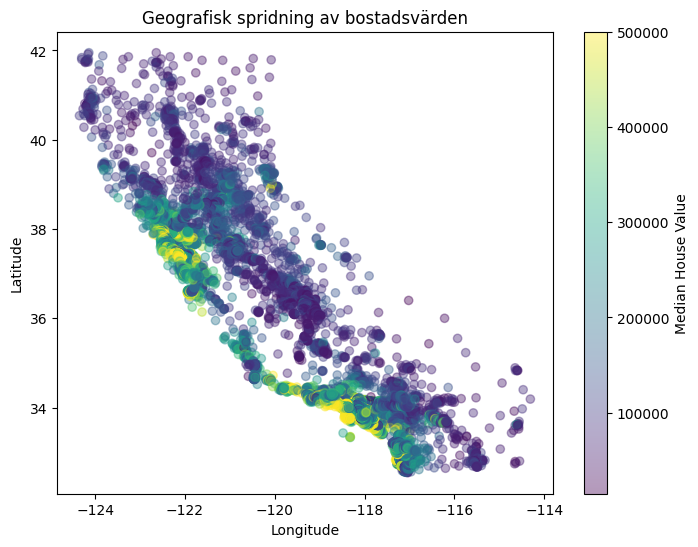

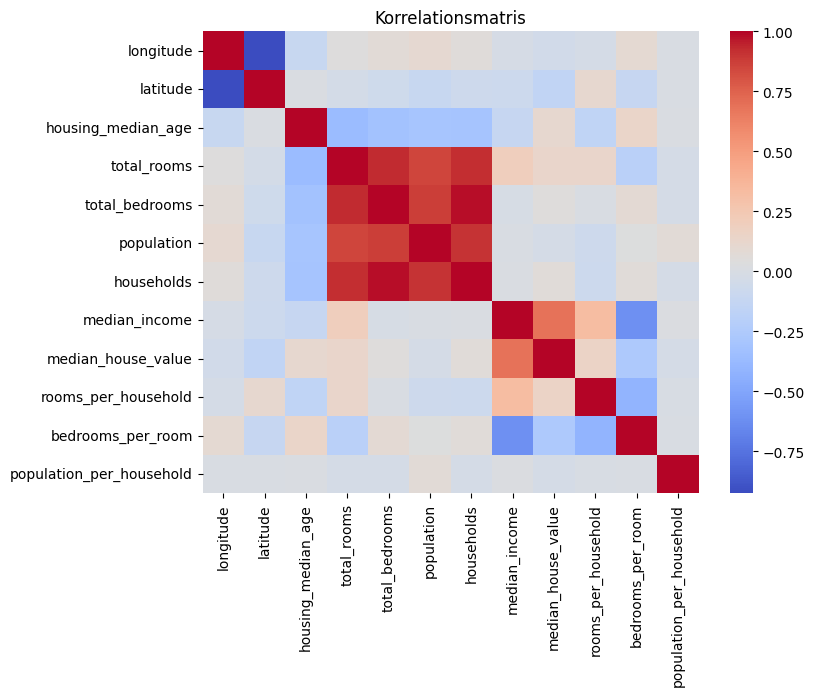

In [25]:
plt.figure(figsize=(7,4))
sns.histplot(df["median_house_value"], kde=True)
plt.title("Distribution av median bostadsvärden")
plt.xlabel("Median bostadsvärde (USD)")
plt.ylabel("Antal distrikt")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(df["longitude"], df["latitude"],
            c=df["median_house_value"],
            cmap="viridis", alpha=0.4)
plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geografisk spridning av bostadsvärden")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Korrelationsmatris")
plt.show()

### Figurer

Den översta figuren, histplot, kan man avläsa är högerskev med en tydlig övre gräns (runt 500 000), vilket kan påverka modellens precision vid höga värden.

Figur 2, geografisk spridning av husvärden, här kan man se att geografi påverkar värdet, där priserna är högre nära kusten.

Figur 3, korrelationsmatris, visar en positiv korrelation mellan medianinkomst och bostadsvärde, och man kan även se här att geografi påverkar värdet. 

## Split + preprocessing

In [7]:
target_col = "median_house_value"
X = df.drop(columns=[target_col])
y = df[target_col]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

numerical_features = X_train.select_dtypes(include=["int64","float64"]).columns
categorical_features = ["ocean_proximity"]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train positive rate:", y_train.mean().round(3), "Test positive rate:", y_test.mean().round(3))

Train: (15480, 12) Test: (5160, 12)
Train positive rate: 207034.892 Test positive rate: 206318.591


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

## Modellering

Här används Dummyregressor som baseline, och Linear Regression och Random Forest för de andra modellerna att träna datan på


In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_model(model, X, y):
    scores = cross_val_score(
        model, 
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=kf
    )
    return -scores.mean()

### Baseline

In [11]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline_scores = cv_model(baseline_model, X_train, y_train)
print(baseline_scores.mean())

115522.20221816306


### Linear regression

In [12]:
linear_reg_pl = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])

lin_reg_scores = cv_model(linear_reg_pl, X_train, y_train)

print(lin_reg_scores)

68088.0021208918


### Random forest

In [13]:
rand_forest_pl = Pipeline([
    ("preprocessor", preprocessor), 
    ("model", RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE))
    ])

rand_forest_scores = cv_model(rand_forest_pl, X_train, y_train)

print(rand_forest_scores.mean())

50559.796357523795


In [14]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "CV_RMSE": [
        baseline_scores,
        lin_reg_scores,
        rand_forest_scores
    ]
})

results.sort_values("CV_RMSE")

,Model,CV_RMSE
2,Random Forest,50559.796358
1,Linear Regression,68088.002121
0,Baseline,115522.202218


RMSE valdes då den straffar stora fel mer. Inom fastighetsvärdering är stora fel mer problematiska än små. 

Man vill ha lägre RMSE, vilket man kan se att Random Forest har och presterade därmed bäst av alla modellerna. 

## Optimera en modell

Här valdes Random Forest för optimering då den presterade bäst under utvärderingen (CV)

In [15]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rand_forest_pl,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [16]:
grid_search.fit(X_train, y_train)
print("Bäst CV score:", -grid_search.best_score_)
print("Bäst params:", grid_search.best_params_)

Bäst CV score: 51076.18895370418
Bäst params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [17]:
def evaluate_regression(y_true, y_pred) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

Hyperparameteroptimering gjordes med GridSearchCV och en 5-fold cross-validation.

Valde att optimera följande parametrar:
- Antalet träd ```n_estimators```
- Trädens djup ```max_depth```
- Hur lätt träden delar upp datan ```min_samples_split```
- Hur stora bladnoderna får vara ```min_samples_leaf```

Metric att optimera mot är ```neg_root_mean_squared_error```.

## Utvärdering testdata

In [18]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

test_results = evaluate_regression(y_test, y_pred)

results_df = pd.DataFrame([test_results])
results_df.insert(0, "Model", "Random Forest (Tuned)")

results_df

,Model,MAE,RMSE,R2
0,Random Forest (Tuned),31838.799127,49152.45135,0.817418


In [19]:
baseline_model.fit(X_train, y_train)
linear_reg_pl.fit(X_train, y_train)
rand_forest_pl.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
lin_pred = linear_reg_pl.predict(X_test)
rf_pred = rand_forest_pl.predict(X_test)
best_pred = best_model.predict(X_test)

baseline_results = evaluate_regression(y_test, baseline_pred)
lin_results = evaluate_regression(y_test, lin_pred)
rf_results = evaluate_regression(y_test, rf_pred)
best_results = evaluate_regression(y_test, best_pred)

results_df = pd.DataFrame([
    {"Model": "Baseline (Dummy)", **baseline_results},
    {"Model": "Linear Regression", **lin_results},
    {"Model": "Random Forest", **rf_results},
    {"Model": "Random Forest (Tuned)", **best_results},
])

results_df

,Model,MAE,RMSE,R2
0,Baseline (Dummy),91004.749905,115033.447900,-0.000039
1,Linear Regression,49355.754508,68429.860721,0.646117
2,Random Forest,31925.663151,49264.520882,0.816584
3,Random Forest (Tuned),31838.799127,49152.451350,0.817418


## Resultat

Valde tre modeller att träna datan på: Dummyregressor (baseline), Linear Regression och Forest Regressor. 

Modellerna implementerades i en gemensam pipeline med preprocessing för att undvika data leakage.

Modellerna jämfördes sedan med en 5-fold cross-validation och RMSE som utvärderingsmetod.
Random Forest hade lägst RMSE och valdes som den slutliga modellen för testdatan.

Valet föll till RMSE då den straffar stora prediktionsfel mer, vilket är passande där stora värderingsfel innebär en hög risk.

## Rekommendation

Som man kan se från tabellen lite högre upp, så presterade den optimerade Random Forest tabellen bäst på testdatan, med lägst RMSE och MAE, samt högst R^2.
Med det menas att modellen ger mer exakta prediktioner än de andra modellerna. 

En annan fördel med Random Forest är att den kan hantera icke-linjära interaktioner mellan variabler, vilket passar för bostadsdata av denna typ.

Med andra ord så rekommenderas den optimerade Random Forest modellen som beslutsstöd för att uppskatta bostadsvärden i olika områden.